# Maproom hindcast review

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
from src.datasources.era5 import fetch_era5_data
from src.datasources.seas5 import fetch_seas5_data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from affine import Affine
from rasterstats import zonal_stats
import calendar

In [3]:
pd.options.display.float_format = "{:,.3f}".format

In [4]:
# hindcasts by region
somali_mam_region_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - Somali Region (region).csv"
somali_ond_region_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA OND Trigger Documentation and Metrics - Somali Region (region).csv"
oromia_mam_region_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP FbF Ethiopia 2023 MAM Trigger Documentation and Metrics - Oromia Region (region).csv"
oromia_ond_region_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - Oromia Region (region).csv"
south_mam_region_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - South Ethiopia Region (region).csv"
south_ond_region_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - South Ethiopia Region (region).csv"

In [21]:
# use stratus to read in hindcasts
somali_mam_region_df = stratus.load_csv_from_blob(
    somali_mam_region_hindcast, stage="dev", container_name="projects"
)
somali_mam_region_df["Region"] = "Somali"
somali_ond_region_df = stratus.load_csv_from_blob(
    somali_ond_region_hindcast, stage="dev", container_name="projects"
)
somali_ond_region_df["Region"] = "Somali"
oromia_mam_region_df = stratus.load_csv_from_blob(
    oromia_mam_region_hindcast, stage="dev", container_name="projects"
)
oromia_mam_region_df["Region"] = "Oromia"
oromia_ond_region_df = stratus.load_csv_from_blob(
    oromia_ond_region_hindcast, stage="dev", container_name="projects"
)
oromia_ond_region_df["Region"] = "Oromia"
south_mam_region_df = stratus.load_csv_from_blob(
    south_mam_region_hindcast, stage="dev", container_name="projects"
)
south_mam_region_df["Region"] = "South Ethiopia"
south_ond_region_df = stratus.load_csv_from_blob(
    south_ond_region_hindcast, stage="dev", container_name="projects"
)
south_ond_region_df["Region"] = "South Ethiopia"
mam_region_hindcast = pd.concat(
    [somali_mam_region_df, oromia_mam_region_df, south_mam_region_df], ignore_index=True
)
ond_region_hindcast = pd.concat(
    [somali_ond_region_df, oromia_ond_region_df, south_ond_region_df], ignore_index=True
)
ond_region_hindcast.head()

,Issue Year,Issue Month,ENSO State,Severity,Action Frequency,Forecast Prob. Non-Exceedence,Curr. NDVI,Prev. MAM Rainfall,Trigger Threshold,Adjusted Trigger Threshold,Triggered?,Region,Year
0,"2,024.000",Jul,NaN,Severe,20%,37.580,NaN,NaN,37.550,NaN,NaN,Somali,NaN
1,"2,023.000",Jul,NaN,Severe,20%,13.540,Above Normal,Above Normal,37.550,37.550,No,Somali,NaN
2,"2,022.000",Jul,La Niña,Severe,20%,37.850,Below Normal,Below Normal,37.550,32.550,Yes,Somali,NaN
3,"2,021.000",Jul,La Niña,Severe,20%,38.130,Above Normal,Above Normal,37.550,37.550,Yes,Somali,NaN
4,"2,020.000",Jul,Neutral,Severe,20%,42.860,Above Normal,Above Normal,37.550,37.550,Yes,Somali,NaN


In [ ]:
# adding some more information
# ond_region_hindcast["Adjusted Trigger Threshold"] = (
#    ond_region_hindcast["Adjusted Trigger Threshold"]
#    .replace("", pd.NA)
#    .fillna(ond_region_hindcast["Trigger Threshold"])
# )
# If NDVI is missing → assume Below
ond_region_hindcast.loc[
    ond_region_hindcast["Curr. NDVI"].isna()
    | (ond_region_hindcast["Curr. NDVI"].astype(str).str.strip() == ""),
    "Curr. NDVI",
] = "Below Normal"

# If MAM is missing → assume Below
ond_region_hindcast.loc[
    ond_region_hindcast["Prev. MAM Rainfall"].isna()
    | (ond_region_hindcast["Prev. MAM Rainfall"].astype(str).str.strip() == ""),
    "Prev. MAM Rainfall",
] = "Below Normal"
# NDVI = Below, MAM = Above
mask = (
    (ond_region_hindcast["Curr. NDVI"] == "Below Normal")
    & (ond_region_hindcast["Prev. MAM Rainfall"] == "Above Normal")
    & (ond_region_hindcast["Adjusted Trigger Threshold"].isna())
)

ond_region_hindcast.loc[
    mask & (ond_region_hindcast["Issue Month"] == "Jul"), "Adjusted Trigger Threshold"
] = (
    ond_region_hindcast.loc[
        mask & (ond_region_hindcast["Issue Month"] == "Jul"), "Trigger Threshold"
    ]
    * 0.960053
)

ond_region_hindcast.loc[
    mask & (ond_region_hindcast["Issue Month"] == "Aug"), "Adjusted Trigger Threshold"
] = (
    ond_region_hindcast.loc[
        mask & (ond_region_hindcast["Issue Month"] == "Aug"), "Trigger Threshold"
    ]
    * 0.960401
)

ond_region_hindcast.loc[
    mask & (ond_region_hindcast["Issue Month"] == "Sep"), "Adjusted Trigger Threshold"
] = (
    ond_region_hindcast.loc[
        mask & (ond_region_hindcast["Issue Month"] == "Sep"), "Trigger Threshold"
    ]
    * 0.96
)


# NDVI = Below, MAM = Below
mask = (
    (ond_region_hindcast["Curr. NDVI"] == "Below Normal")
    & (ond_region_hindcast["Prev. MAM Rainfall"] == "Below Normal")
    & (ond_region_hindcast["Adjusted Trigger Threshold"].isna())
)

ond_region_hindcast.loc[
    mask & (ond_region_hindcast["Issue Month"] == "Jul"), "Adjusted Trigger Threshold"
] = (
    ond_region_hindcast.loc[
        mask & (ond_region_hindcast["Issue Month"] == "Jul"), "Trigger Threshold"
    ]
    * 0.866844
)

ond_region_hindcast.loc[
    mask & (ond_region_hindcast["Issue Month"] == "Aug"), "Adjusted Trigger Threshold"
] = (
    ond_region_hindcast.loc[
        mask & (ond_region_hindcast["Issue Month"] == "Aug"), "Trigger Threshold"
    ]
    * 0.868004
)

ond_region_hindcast.loc[
    mask & (ond_region_hindcast["Issue Month"] == "Sep"), "Adjusted Trigger Threshold"
] = (
    ond_region_hindcast.loc[
        mask & (ond_region_hindcast["Issue Month"] == "Sep"), "Trigger Threshold"
    ]
    * 0.857509
)

# adding missing Triggered values
ond_region_hindcast["Triggered?"] = ond_region_hindcast.apply(
    lambda row: (
        "Yes"
        if (pd.isna(row["Triggered?"]) or str(row["Triggered?"]).strip() == "")
        and row["Forecast Prob. Non-Exceedence"] >= row["Adjusted Trigger Threshold"]
        else (
            "No"
            if (pd.isna(row["Triggered?"]) or str(row["Triggered?"]).strip() == "")
            else row["Triggered?"]
        )
    ),
    axis=1,
)
ond_region_hindcast.head()

,Issue Year,Issue Month,ENSO State,Severity,Action Frequency,Forecast Prob. Non-Exceedence,Curr. NDVI,Prev. MAM Rainfall,Trigger Threshold,Adjusted Trigger Threshold,Triggered?,Region,Year
0,"2,024.000",Jul,NaN,Severe,20%,37.580,Below Normal,Below Normal,37.550,32.550,Yes,Somali,NaN
1,"2,023.000",Jul,NaN,Severe,20%,13.540,Above Normal,Above Normal,37.550,37.550,No,Somali,NaN
2,"2,022.000",Jul,La Niña,Severe,20%,37.850,Below Normal,Below Normal,37.550,32.550,Yes,Somali,NaN
3,"2,021.000",Jul,La Niña,Severe,20%,38.130,Above Normal,Above Normal,37.550,37.550,Yes,Somali,NaN
4,"2,020.000",Jul,Neutral,Severe,20%,42.860,Above Normal,Above Normal,37.550,37.550,Yes,Somali,NaN


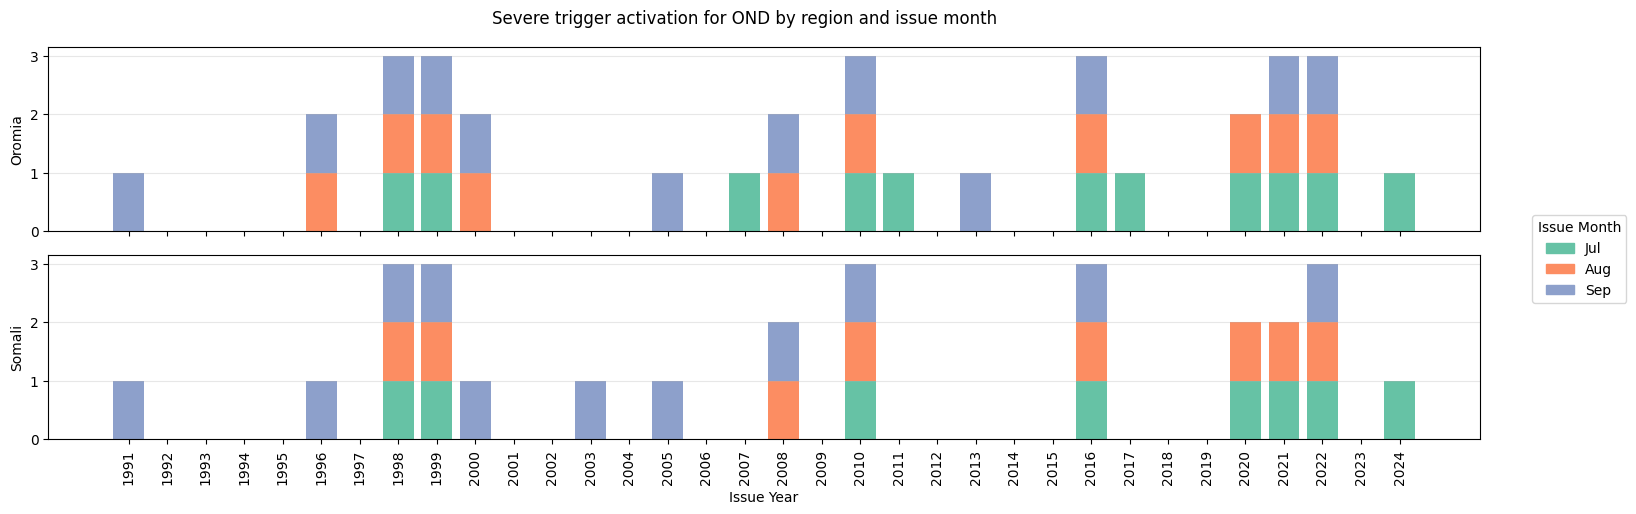

In [23]:
all_years = list(
    range(
        int(ond_region_hindcast["Issue Year"].min()),
        int(ond_region_hindcast["Issue Year"].max()) + 1,
    )
)
all_years = all_years[all_years.index(1991) :]
df_filt = ond_region_hindcast[
    (ond_region_hindcast["Severity"] == "Severe")
    & (ond_region_hindcast["Triggered?"] == "Yes")
].copy()

years = list(all_years)

month_order = list(calendar.month_abbr)[1:]
months = [m for m in month_order if m in df_filt["Issue Month"].unique()]

agg = (
    df_filt.groupby(["Issue Year", "Region", "Issue Month"])
    .size()
    .reset_index(name="triggered")
)

regions = sorted(agg["Region"].unique())
palette = plt.get_cmap("Set2")
month_colors = {m: palette(i) for i, m in enumerate(months)}

fig, axes = plt.subplots(
    nrows=len(regions),
    ncols=1,
    figsize=(15, 2.6 * len(regions)),
    sharex=True,
)

if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):

    bottom = np.zeros(len(years))

    for m in months:
        vals = (
            agg[(agg["Region"] == region) & (agg["Issue Month"] == m)]
            .set_index("Issue Year")["triggered"]
            .reindex(years, fill_value=0)
            .values
        )

        ax.bar(
            years,
            vals,
            bottom=bottom,
            color=month_colors[m],
            edgecolor="none",
            width=0.8,
        )

        bottom += vals

    ax.set_ylabel(region)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Issue Year")
for ax in axes:
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=90)

handles = [plt.Rectangle((0, 0), 1, 1, color=month_colors[m]) for m in months]

fig.legend(
    handles,
    months,
    title="Issue Month",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
)

fig.suptitle(
    "Severe trigger activation for OND by region and issue month",
    y=0.98,
)

plt.tight_layout()
plt.show()

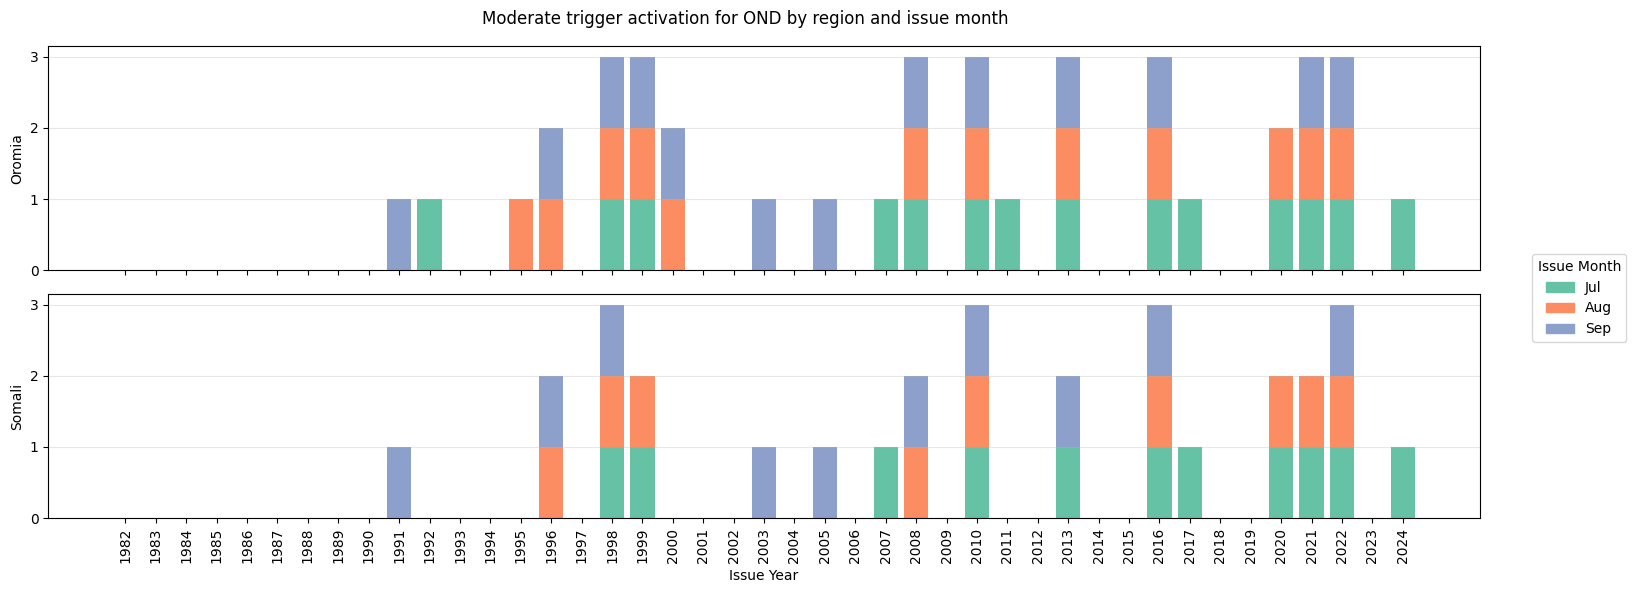

In [8]:
all_years = list(
    range(
        int(ond_region_hindcast["Issue Year"].min()),
        int(ond_region_hindcast["Issue Year"].max()) + 1,
    )
)

df_filt = ond_region_hindcast[
    (ond_region_hindcast["Severity"] == "Moderate")
    & (ond_region_hindcast["Triggered?"] == "Yes")
].copy()

years = list(all_years)

month_order = list(calendar.month_abbr)[1:]
months = [m for m in month_order if m in df_filt["Issue Month"].unique()]

agg = (
    df_filt.groupby(["Issue Year", "Region", "Issue Month"])
    .size()
    .reset_index(name="triggered")
)

regions = sorted(agg["Region"].unique())
palette = plt.get_cmap("Set2")
month_colors = {m: palette(i) for i, m in enumerate(months)}

fig, axes = plt.subplots(
    nrows=len(regions),
    ncols=1,
    figsize=(15, 3 * len(regions)),
    sharex=True,
)

if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):

    bottom = np.zeros(len(years))

    for m in months:
        vals = (
            agg[(agg["Region"] == region) & (agg["Issue Month"] == m)]
            .set_index("Issue Year")["triggered"]
            .reindex(years, fill_value=0)
            .values
        )

        ax.bar(
            years,
            vals,
            bottom=bottom,
            color=month_colors[m],
            edgecolor="none",
            width=0.8,
        )

        bottom += vals

    ax.set_ylabel(region)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Issue Year")
for ax in axes:
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=90)

handles = [plt.Rectangle((0, 0), 1, 1, color=month_colors[m]) for m in months]

fig.legend(
    handles,
    months,
    title="Issue Month",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
)

fig.suptitle(
    "Moderate trigger activation for OND by region and issue month",
    y=0.98,
)

plt.tight_layout()
plt.show()

In [9]:
# maproom hindcasts
somali_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - Somali Region.csv"
somali_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA OND Trigger Documentation and Metrics - Somali Region.csv"
oromia_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP FbF Ethiopia 2023 MAM Trigger Documentation and Metrics - Oromia Region.csv"
oromia_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - Oromia Region (1).csv"
south_mam_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP Ethiopia AA MAM Trigger Documentation and Metrics - South Ethiopia Region.csv"
south_ond_maproom_hindcast = "ds-aa-eth-drought/exploration/maproom/hindcasts/WFP AA Ethiopia OND Trigger Documentation and Metrics - South Ethiopia Region.csv"

In [10]:
somali_mam_hindcast = stratus.load_csv_from_blob(
    somali_mam_maproom_hindcast, stage="dev", container_name="projects"
)
somali_mam_hindcast["Region"] = "Somali"
oromia_mam_hindcast = stratus.load_csv_from_blob(
    oromia_mam_maproom_hindcast, stage="dev", container_name="projects"
)
oromia_mam_hindcast["Region"] = "Oromia"
south_mam_hindcast = stratus.load_csv_from_blob(
    south_mam_maproom_hindcast, stage="dev", container_name="projects"
)
south_mam_hindcast["Region"] = "South Ethiopia"
mam_maproom_hindcast = pd.concat(
    [somali_mam_hindcast, oromia_mam_hindcast, south_mam_hindcast], ignore_index=True
)

In [11]:
somali_ond_hindcast = stratus.load_csv_from_blob(
    somali_ond_maproom_hindcast, stage="dev", container_name="projects"
)
somali_ond_hindcast["Region"] = "Somali"
oromia_ond_hindcast = stratus.load_csv_from_blob(
    oromia_ond_maproom_hindcast, stage="dev", container_name="projects"
)
oromia_ond_hindcast["Region"] = "Oromia"
south_ond_hindcast = stratus.load_csv_from_blob(
    south_ond_maproom_hindcast, stage="dev", container_name="projects"
)
south_ond_hindcast["Region"] = "South Ethiopia"
ond_maproom_hindcast = pd.concat(
    [somali_ond_hindcast, oromia_ond_hindcast, south_ond_hindcast], ignore_index=True
)
ond_maproom_hindcast.head()

,Issue Year,Issue Month,ENSO State,Woreda,Severity,Action Frequency,Forecast Prob. Non-Exceedence,Curr. NDVI,Prev. MAM Rainfall,Trigger Threshold,Adjusted Trigger Threshold,Triggered?,Region,Year,Zone
0,"2,024.000",Jul,NaN,Aba-Korow,Severe,20%,38.070,NaN,NaN,38.060,NaN,NaN,Somali,NaN,NaN
1,"2,023.000",Jul,NaN,Aba-Korow,Severe,20%,11.360,Above Normal,Above Normal,38.060,38.060,No,Somali,NaN,NaN
2,"2,022.000",Jul,La Niña,Aba-Korow,Severe,20%,38.630,Below Normal,Below Normal,38.060,33.060,Yes,Somali,NaN,NaN
3,"2,021.000",Jul,La Niña,Aba-Korow,Severe,20%,38.060,Above Normal,Above Normal,38.060,38.060,Yes,Somali,NaN,NaN
4,"2,020.000",Jul,Neutral,Aba-Korow,Severe,20%,43.470,Above Normal,Above Normal,38.060,38.060,Yes,Somali,NaN,NaN


In [12]:
def build_forecast_table(
    hindcast_df,
    issue_month_map,
    severity_filter="Severe",
    val_cols=("ENSO State", "Action Frequency"),
    plot_heatmap=False,
    plot_skill=False,
    highlight_value=None,
    N_events=7,
    drought_years=None,
):
    """
    Forecast analogue of build_season_table().
    - Count severe woredas per Issue Year + Issue Month
    - Heatmap identical in shape to SEAS5 drought heatmap
    - Metrics (HR, FAR, MR) based on driest N_events from NDVI or rainfall
    """

    df = hindcast_df.copy()

    df = df[(df["Severity"] == severity_filter) & (df["Triggered?"] == "Yes")].copy()

    severe_counts = (
        df.groupby(["Issue Year", "Issue Month"])
        .size()
        .reset_index(name="severe_count")
    )

    pivot = severe_counts.pivot_table(
        index="Issue Month", columns="Issue Year", values="severe_count", fill_value=0
    )
    all_years = range(
        int(hindcast_df["Issue Year"].min()),
        int(hindcast_df["Issue Year"].max()) + 1,
    )
    pivot = pivot.reindex(columns=all_years, fill_value=0)

    pivot.index = pivot.index.map(issue_month_map)

    pivot = pivot.groupby(pivot.index).sum()

    pivot = pivot.reindex(sorted(issue_month_map.values(), reverse=True))

    if plot_heatmap:

        plt.figure(figsize=(16, 4))
        sns.heatmap(pivot, annot=True, cmap="YlOrBr", fmt="g", linewidths=0.4)
        plt.title(
            "EMI/IRI WFP Maproom Hindcast Severe Threshold Woreda Counts (Somali, Oromia and South Ethiopia Regions)"
        )

        plt.xlabel("Issue Year")
        plt.ylabel("Lead Time")
        plt.tight_layout()
        plt.show()

    obs_event = pd.Series(
        [1 if y in drought_years else 0 for y in all_years], index=all_years
    )
    if plot_skill and isinstance(drought_years, list):

        if isinstance(drought_years, list):
            obs_event = pd.Series(
                [1 if y in drought_years else 0 for y in all_years], index=all_years
            )
        else:
            raise ValueError("observed_years must be a list of years")

        max_zones = int(pivot.values.max())
        thresholds = np.arange(1, max_zones + 1)

        lt_names = list(pivot.index)
        fig, axes = plt.subplots(
            1, len(lt_names), figsize=(5 * len(lt_names), 4), sharex=True, sharey=True
        )
        if len(lt_names) == 1:
            axes = [axes]

        for ax, lt_name in zip(axes, lt_names):

            fc_values = pivot.loc[lt_name].reindex(all_years)

            hit_rates = []
            false_rates = []
            miss_rates = []

            for T in thresholds:
                # Forecast event: ≥ T severe woredas
                fc = fc_values.apply(lambda z: 1 if z >= T else 0)

                obs = obs_event

                hits = ((fc == 1) & (obs == 1)).sum()
                misses = ((fc == 0) & (obs == 1)).sum()
                false_alarms = ((fc == 1) & (obs == 0)).sum()
                correct_neg = ((fc == 0) & (obs == 0)).sum()

                HR = hits / (hits + misses) if (hits + misses) else 0
                FAR = (
                    false_alarms / (false_alarms + correct_neg)
                    if (false_alarms + correct_neg)
                    else 0
                )
                MR = misses / (hits + misses) if (hits + misses) else 0

                hit_rates.append(HR)
                false_rates.append(FAR)
                miss_rates.append(MR)

            # Plot
            ax.plot(thresholds, hit_rates, label="Hit Rate")
            ax.plot(thresholds, false_rates, label="False Alarm Rate")
            ax.plot(thresholds, miss_rates, label="Miss Rate")

            # Highlight chosen threshold
            if highlight_value is not None:
                T = int(highlight_value)
                if T <= max(thresholds):
                    ax.axvline(T, color="red", linestyle="--")
                    ax.scatter([T], [hit_rates[T - 1]], color="black", s=50)
                    ax.scatter([T], [false_rates[T - 1]], color="black", s=50)
                    ax.scatter([T], [miss_rates[T - 1]], color="black", s=50)

            ax.set_title(f"{lt_name}")
            ax.grid(alpha=0.3)

        fig.supxlabel("Threshold (Number of Woredas reaching the Severe Threshold)")
        fig.supylabel("Metric Value")
        fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=3)

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()

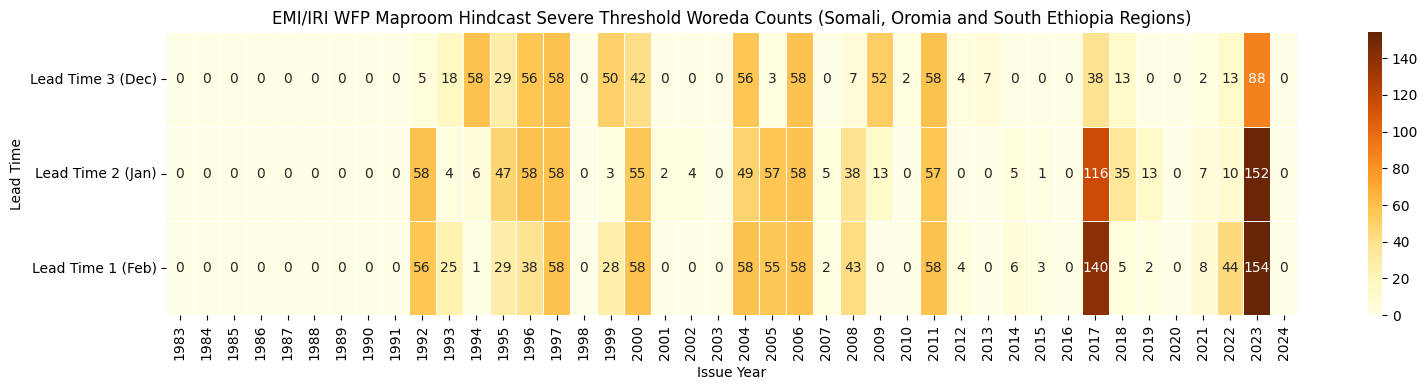

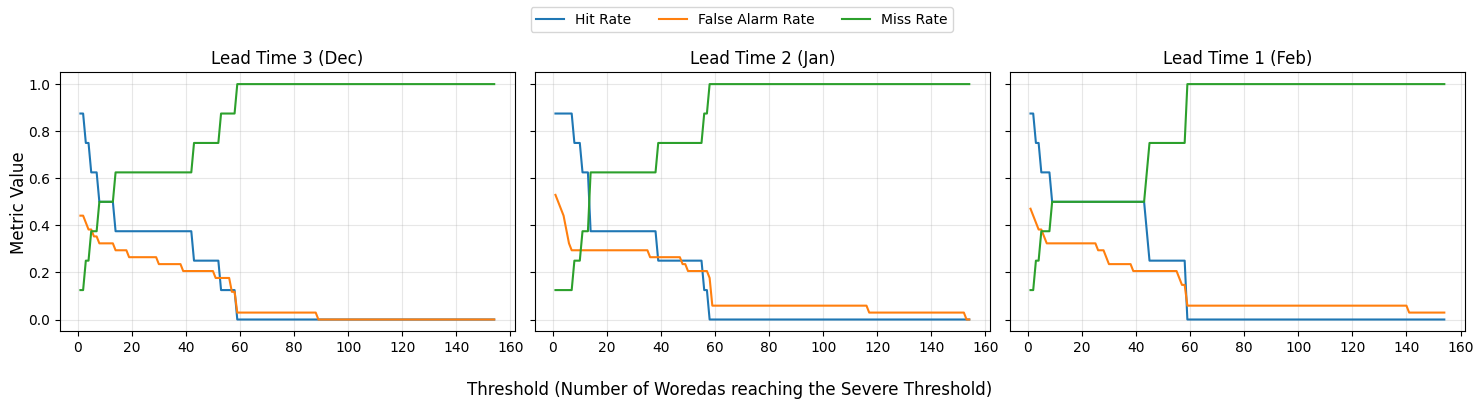

In [13]:
issue_month_map = {
    "Dec": "Lead Time 3 (Dec)",
    "Jan": "Lead Time 2 (Jan)",
    "Feb": "Lead Time 1 (Feb)",
}

forecast_heatmap = build_forecast_table(
    mam_maproom_hindcast,
    issue_month_map,
    severity_filter="Severe",
    val_cols=("ENSO State", "Action Frequency"),
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=None,
    N_events=7,
    drought_years=[2022, 2009, 2000, 2008, 2021, 2011, 2019, 2012],
)

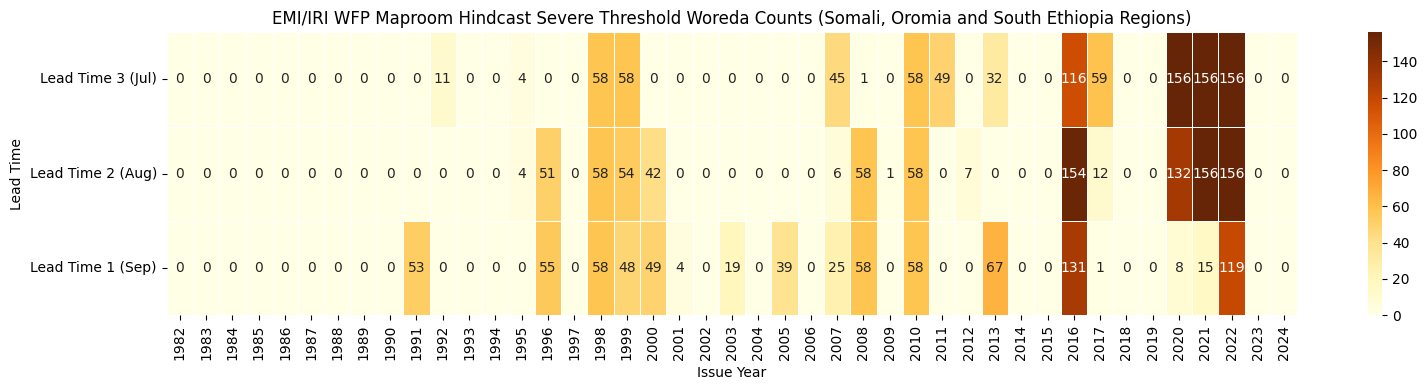

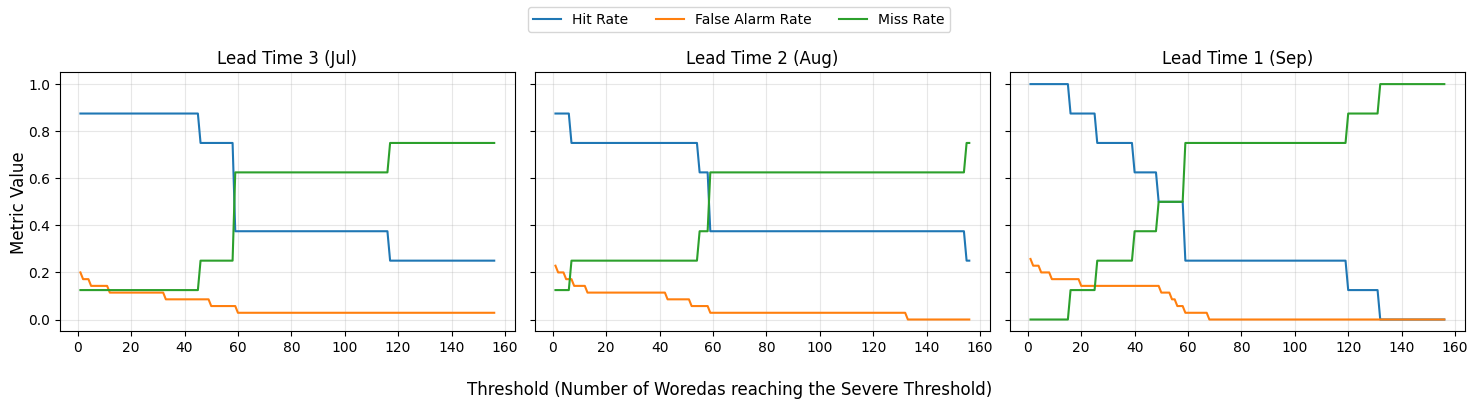

In [14]:
issue_month_map = {
    "Jul": "Lead Time 3 (Jul)",
    "Aug": "Lead Time 2 (Aug)",
    "Sep": "Lead Time 1 (Sep)",
}

forecast_heatmap = build_forecast_table(
    ond_maproom_hindcast,
    issue_month_map,
    severity_filter="Severe",
    val_cols=("ENSO State", "Action Frequency"),
    plot_heatmap=True,
    plot_skill=True,
    highlight_value=None,
    N_events=7,
    drought_years=[2021, 2010, 2022, 1998, 2016, 2007, 1999, 2005],
)